In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tsa.api import VAR 
from statsmodels.tsa.stattools import grangercausalitytests, adfuller, kpss
import warnings
warnings.filterwarnings('ignore')

import sys

sys.path.append('..')

from src.models import GARCHPollution

In [2]:
from pathlib import Path

ROOT = Path('..').resolve()

In [3]:
df = pd.read_csv(ROOT / 'data' / 'csi300_pollution_s2_df.csv', index_col='Date', parse_dates=True)

# III. Econometrics

## 1. Correlation

In [4]:
vars_of_interest = ['pm25', 'realized_vol', 'vix', 'usdcnh']

# Pearson (linear)
pearson_r,  pearson_p  = stats.pearsonr(df['pm25'], df['realized_vol'])

# Spearman (monotonic, rank-based)
spearman_r, spearman_p = stats.spearmanr(df['pm25'], df['realized_vol'])

# Kendall (concordance pairs)
kendall_t,  kendall_p  = stats.kendalltau(df['pm25'], df['realized_vol'])

results = pd.DataFrame({
    'Correlation': [pearson_r,  spearman_r, kendall_t],
    'P-value':     [pearson_p,  spearman_p, kendall_p],
    'Significant': [pearson_p  < 0.05,
                    spearman_p < 0.05,
                    kendall_p  < 0.05]
}, index=['Pearson', 'Spearman', 'Kendall'])

print(results.round(5))

          Correlation  P-value  Significant
Pearson       0.09860  0.00000         True
Spearman      0.06944  0.00044         True
Kendall       0.04607  0.00050         True


In [5]:
lag_cols = ['pm25'] + [f'pm25_lag{i}' for i in range(1, 6)]
results = []

for col in lag_cols:
    r,  p  = stats.spearmanr(df[col], df['realized_vol'])
    results.append({'feature': col, 'spearman_r': r, 'p_value': p})

lag_df = pd.DataFrame(results).round(5)
print(lag_df)

     feature  spearman_r  p_value
0       pm25     0.06944  0.00044
1  pm25_lag1     0.07914  0.00006
2  pm25_lag2     0.08152  0.00004
3  pm25_lag3     0.08312  0.00003
4  pm25_lag4     0.08196  0.00003
5  pm25_lag5     0.08259  0.00003


Lagged correlations reveal that the pollution-volatility relationship strengthens over a 1–5 day horizon, peaking at lag 3 (ρ=0.083, p<0.001). This pattern is consistent with H2 and suggests a gradual transmission mechanism rather than an immediate market response.

## 2. OLS

In [ ]:
# ── Baseline model : pm25_lag3 only ──────────────────────────────
m1 = smf.ols('realized_vol ~ pm25_lag3', data=df).fit()

# ── With controls ─────────────────────────────────────────────────
m2 = smf.ols('realized_vol ~ pm25_lag3 + vix + usdcnh', data=df).fit()

# ── With controls + monthly dummies (seasonality) ─────────────────
df['month'] = df.index.month.astype(str)
m3 = smf.ols('realized_vol ~ pm25_lag3 + vix + usdcnh + C(month)', data=df).fit()

# ── With ma5 instead of lag3 (robustness check) ───────────────────
m4 = smf.ols('realized_vol ~ pm25_ma5 + vix + usdcnh + C(month)', data=df).fit()

# ── Summary table ─────────────────────────────────────────────────
from statsmodels.iolib.summary2 import summary_col

table = summary_col(
    [m1, m2, m3, m4],
    model_names=['Baseline', '+Controls', '+Seasonality', 'MA5'],
    stars=True,
    info_dict={'N': lambda x: f"{int(x.nobs)}",
               'R²': lambda x: f"{x.rsquared:.4f}"}
)
print(table)


                Baseline +Controls  +Seasonality    MA5    
-----------------------------------------------------------
Intercept      0.1719*** 0.8583***  0.8652***    0.7918*** 
               (0.0044)  (0.0407)   (0.0407)     (0.0422)  
pm25_lag3      0.0002*** 0.0001***  0.0002***              
               (0.0000)  (0.0000)   (0.0000)               
vix                      0.0039***  0.0040***    0.0043*** 
                         (0.0003)   (0.0003)     (0.0003)  
usdcnh                   -0.1106*** -0.1138***   -0.1079***
                         (0.0059)   (0.0059)     (0.0059)  
C(month)[T.10]                      0.0335***    0.0346*** 
                                    (0.0097)     (0.0096)  
C(month)[T.11]                      0.0007       -0.0000   
                                    (0.0093)     (0.0092)  
C(month)[T.12]                      -0.0105      -0.0084   
                                    (0.0091)     (0.0091)  
C(month)[T.2]                       0.0

## 2. GARCH models


  GARCHPollution Summary — CSI 300
                                                 Coef   Std Err P-value           Sig
Block         Parameter                                                              
GARCH         omega                          0.023979  0.010163  0.0183            **
              alpha[1]                       0.082192  0.017838     0.0           ***
              beta[1]                        0.906422  0.018545     0.0           ***
              persistence (α+β)              0.988615         —       —  ✓ stationary
Pollution (δ) delta (pm25)                   0.002905  0.000738  0.0001           ***
              95% CI             [0.001459, 0.004350]         —       —             —
              R² (step 2)                      0.0054         —       —             —
Model fit     Log-likelihood                 -4033.87         —       —             —
              AIC                             8075.74         —       —             —
              BIC 

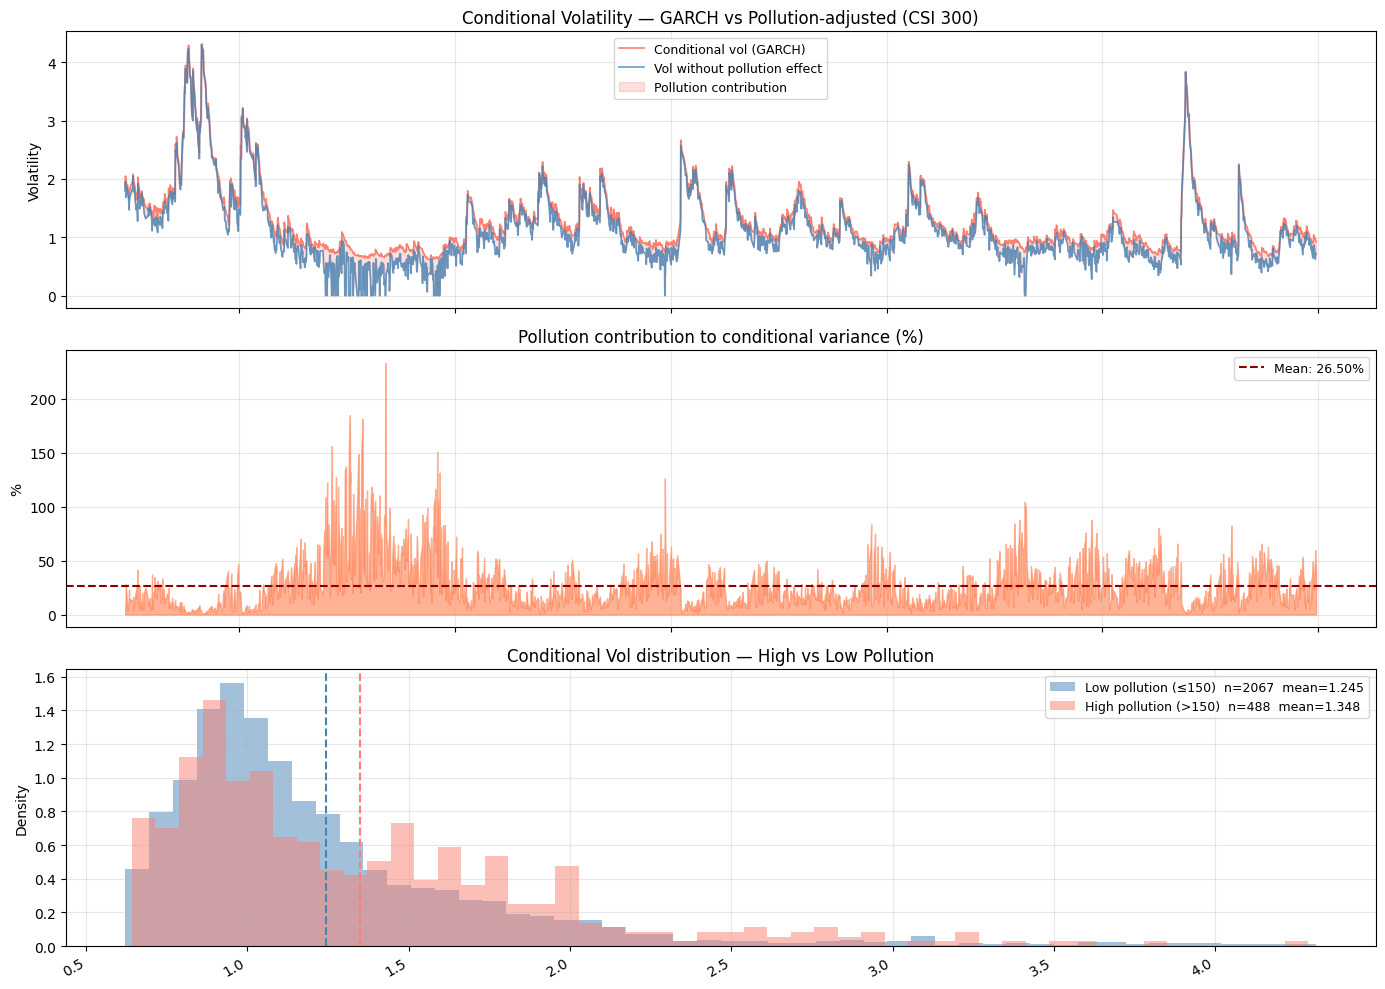

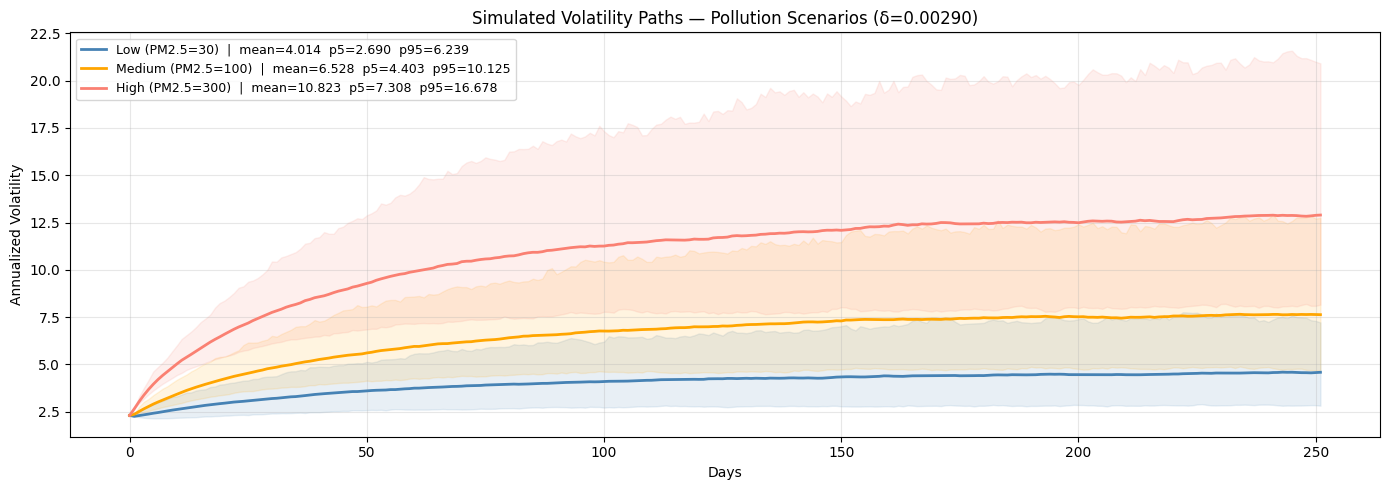

          Scenario  PM2.5  Mean vol  P5 vol  P95 vol
    Low (PM2.5=30)     30    4.0140  2.6904   6.2386
Medium (PM2.5=100)    100    6.5278  4.4029  10.1249
  High (PM2.5=300)    300   10.8230  7.3077  16.6782


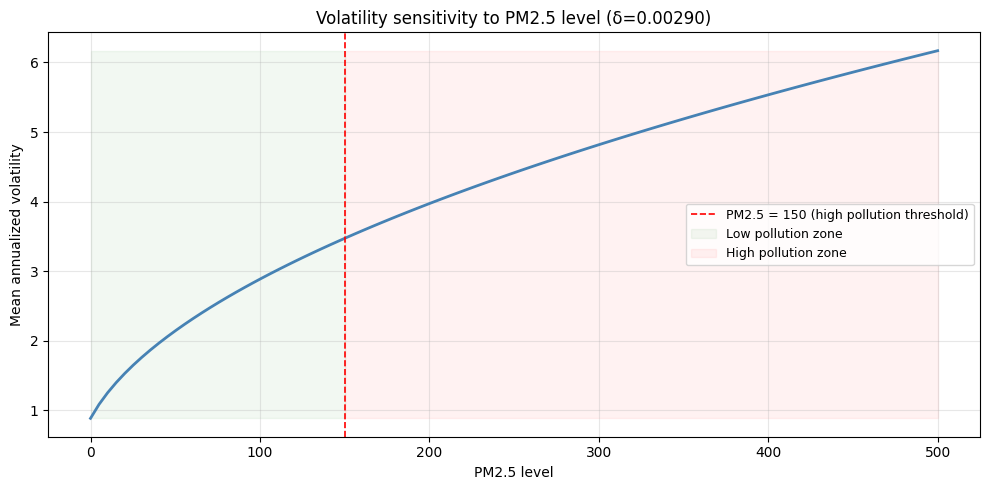

In [7]:
model = GARCHPollution(
    returns    = df['returns'],
    pollution  = df['pm25_lag3'],
    asset_name = 'CSI 300'
)
model.fit(disp=False)

model.summary()

model.plot_effect(threshold=150)

model.simulate_paths({
    'Low (PM2.5=30)':      30,
    'Medium (PM2.5=100)': 100,
    'High (PM2.5=300)':   300,
})

model.plot_delta_sensitivity(pm25_range=(0, 500));

## 3. Granger Causality Test 

In [8]:
df['pm25_diff'] = df['pm25'].diff()
df['rv_diff'] = df['realized_vol'].diff()

df.dropna(subset=['pm25_diff', 'rv_diff'], inplace=True)

In [ ]:
warnings.filterwarnings('ignore', message="The test statistic is outside of the range of p-values available")

def test_stationarity(series, variable_name):
    print(f"--- Tests for: {variable_name} ---")
    series_clean = series.dropna()
    
    # ADF Test
    adf_result = adfuller(series_clean)
    adf_pval = adf_result[1]
    
    print(f"ADF  p-value: {adf_pval:.4f} ", end="")
    if adf_pval < 0.05:
        print("-> Reject H0 (Stationary Series ✅)")
    else:
        print("-> Fail to reject H0 (Non-Stationary Series ❌)")
        
    # KPSS Test
    kpss_result = kpss(series_clean, regression='c', nlags="auto")
    kpss_pval = kpss_result[1]
    
    print(f"KPSS p-value: {kpss_pval:.4f} ", end="")
    if kpss_pval < 0.05:
        print("-> Reject H0 (Non-Stationary Series ❌)")
    else:
        print("-> Fail to reject H0 (Stationary Series ✅)")
        
    print("-" * 55)


variables_to_test = ['pm25_diff', 'rv_diff']


for var in variables_to_test:
    if var in df.columns:
        test_stationarity(df[var], var)
    else:
        print(f"Column '{var}' not found in the DataFrame.")

--- Tests for: pm25_diff ---
ADF  p-value: 0.0000 -> Reject H0 (Stationary Series ✅)
KPSS p-value: 0.1000 -> Fail to reject H0 (Stationary Series ✅)
-------------------------------------------------------
--- Tests for: rv_diff ---
ADF  p-value: 0.0000 -> Reject H0 (Stationary Series ✅)
KPSS p-value: 0.1000 -> Fail to reject H0 (Stationary Series ✅)
-------------------------------------------------------


In [10]:
granger_test = df[['rv_diff','pm25_diff']]

granger_results = grangercausalitytests(granger_test, maxlag=5, verbose=True)

for lag, res in granger_results.items():
    pval = res[0]['ssr_ftest'][1]
    print(f"Lag {lag} → p-value = {pval:.4f}")


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.9522  , p=0.3293  , df_denom=2550, df_num=1
ssr based chi2 test:   chi2=0.9533  , p=0.3289  , df=1
likelihood ratio test: chi2=0.9531  , p=0.3289  , df=1
parameter F test:         F=0.9522  , p=0.3293  , df_denom=2550, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1.2567  , p=0.2848  , df_denom=2547, df_num=2
ssr based chi2 test:   chi2=2.5184  , p=0.2839  , df=2
likelihood ratio test: chi2=2.5172  , p=0.2841  , df=2
parameter F test:         F=1.2567  , p=0.2848  , df_denom=2547, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.6579  , p=0.1740  , df_denom=2544, df_num=3
ssr based chi2 test:   chi2=4.9873  , p=0.1727  , df=3
likelihood ratio test: chi2=4.9824  , p=0.1731  , df=3
parameter F test:         F=1.6579  , p=0.1740  , df_denom=2544, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=1.3119  , p=0.

In [11]:
granger_test_2 = df[['pm25_diff','rv_diff']]

granger_results_2 = grangercausalitytests(granger_test_2, maxlag=5, verbose=True)

for lag, res in granger_results_2.items():
    pval = res[0]['ssr_ftest'][1]
    print(f"Lag {lag} → p-value = {pval:.4f}")


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=4.7323  , p=0.0297  , df_denom=2550, df_num=1
ssr based chi2 test:   chi2=4.7379  , p=0.0295  , df=1
likelihood ratio test: chi2=4.7335  , p=0.0296  , df=1
parameter F test:         F=4.7323  , p=0.0297  , df_denom=2550, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=2.8247  , p=0.0595  , df_denom=2547, df_num=2
ssr based chi2 test:   chi2=5.6606  , p=0.0590  , df=2
likelihood ratio test: chi2=5.6543  , p=0.0592  , df=2
parameter F test:         F=2.8247  , p=0.0595  , df_denom=2547, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=3.6984  , p=0.0113  , df_denom=2544, df_num=3
ssr based chi2 test:   chi2=11.1257 , p=0.0111  , df=3
likelihood ratio test: chi2=11.1015 , p=0.0112  , df=3
parameter F test:         F=3.6984  , p=0.0113  , df_denom=2544, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=2.8876  , p=0.

According to our tests, pollution doesn't Granger-cause realized volatility, but realized volatility Granger-causes pollution. This result is economically consistent : when the VIX rises sharply, reflecting heightened market uncertainty, economic activity tends to contract — firms reduce production, industrial output slows down, and energy consumption drops.

## 4. VAR + IRF

In [ ]:
df['usdcnh_diff'] = df['usdcnh'].diff()
cols_to_use = ['rv_diff', 'pm25_diff', 'vix', 'usdcnh_diff']
data_var = df[cols_to_use].dropna()

SIGNIFICANCE_LEVEL = 0.05
MAX_LAGS = 10
SEPARATOR = "=" * 70

def print_section(title):
    print(f"\n{SEPARATOR}")
    print(f"  {title}")
    print(f"{SEPARATOR}")

def significance(pval, threshold=SIGNIFICANCE_LEVEL):
    return "Significant" if pval < threshold else "Not significant"


# ============================================================
# BIVARIATE GRANGER CAUSALITY (Baseline, No Controls)
# ============================================================

print_section("STEP 1 — BIVARIATE GRANGER CAUSALITY (Baseline, No Controls)")

pairs = {
    "PM2.5  →  Realized Volatility"                 : ('rv_diff',   'pm25_diff'),
    "Realized Volatility  →  PM2.5 (Falsification)" : ('pm25_diff', 'rv_diff'),
}

for label, (dep, indep) in pairs.items():
    print(f"\n  [{label}]")
    print(f"  {'Lag':<6} {'F-stat':>10} {'p-value':>10} {'Result':>20}")
    print(f"  {'-'*50}")
    results = grangercausalitytests(data_var[[dep, indep]], maxlag=5, verbose=False)
    for lag, res in results.items():
        fstat = res[0]['ssr_ftest'][0]
        pval  = res[0]['ssr_ftest'][1]
        print(f"  {lag:<6} {fstat:>10.4f} {pval:>10.4f} {significance(pval):>20}")


# ============================================================
# MULTIVARIATE VAR — OPTIMAL LAG SELECTION
# ============================================================

print_section("STEP 2 — MULTIVARIATE VAR — OPTIMAL LAG SELECTION")

endog   = data_var[['rv_diff', 'pm25_diff', 'vix', 'usdcnh_diff']]
model   = VAR(endog)
lag_sel = model.select_order(maxlags=MAX_LAGS)

print(lag_sel.summary())

lag_optimal = lag_sel.aic
print(f"\n  Optimal lag selected by AIC : {lag_optimal}")

var_results = model.fit(lag_optimal)


# ============================================================
# MULTIVARIATE GRANGER CAUSALITY TEST
# ============================================================

print_section("STEP 3 — MULTIVARIATE GRANGER CAUSALITY TEST (Corrected VAR)")

tests = {
    "PM2.5  →  Realized Volatility"              : ("rv_diff",   "pm25_diff"),
    "Realized Volatility  →  PM2.5 (Robustness)" : ("pm25_diff", "rv_diff"),
}

for label, (caused, causing) in tests.items():
    res   = var_results.test_causality(caused=caused, causing=causing, kind='f')
    pval  = res.pvalue
    fstat = res.test_statistic
    print(f"\n  [{label}]")
    print(f"  F-statistic = {fstat:.4f}   p-value = {pval:.4f}   [{significance(pval)}]")

    if caused == 'rv_diff':
        if pval < SIGNIFICANCE_LEVEL:
            print("  → PM2.5 Granger-causes realized volatility. Hypothesis supported.")
        else:
            print("  → No significant Granger causality from PM2.5 to realized volatility.")
    else:
        if pval < SIGNIFICANCE_LEVEL:
            print("  → Reverse causality detected. Consistent with the activity channel hypothesis.")
        else:
            print("  → No reverse causality. VAR specification is robust.")

print(f"\n{SEPARATOR}\n")


  STEP 1 — BIVARIATE GRANGER CAUSALITY (Baseline, No Controls)

  [PM2.5  →  Realized Volatility]
  Lag        F-stat    p-value               Result
  --------------------------------------------------
  1          0.9463     0.3308      Not significant
  2          1.2375     0.2903      Not significant
  3          1.6487     0.1761      Not significant
  4          1.3082     0.2645      Not significant
  5          1.0737     0.3729      Not significant

  [Realized Volatility  →  PM2.5 (Falsification)]
  Lag        F-stat    p-value               Result
  --------------------------------------------------
  1          4.7106     0.0301          Significant
  2          2.8193     0.0598      Not significant
  3          3.6995     0.0113          Significant
  4          2.8883     0.0212          Significant
  5          2.9423     0.0118          Significant

  STEP 2 — MULTIVARIATE VAR — OPTIMAL LAG SELECTION
 VAR Order Selection (* highlights the minimums)  
       AIC      


  STEP 4 — IMPULSE RESPONSE FUNCTIONS (IRF)


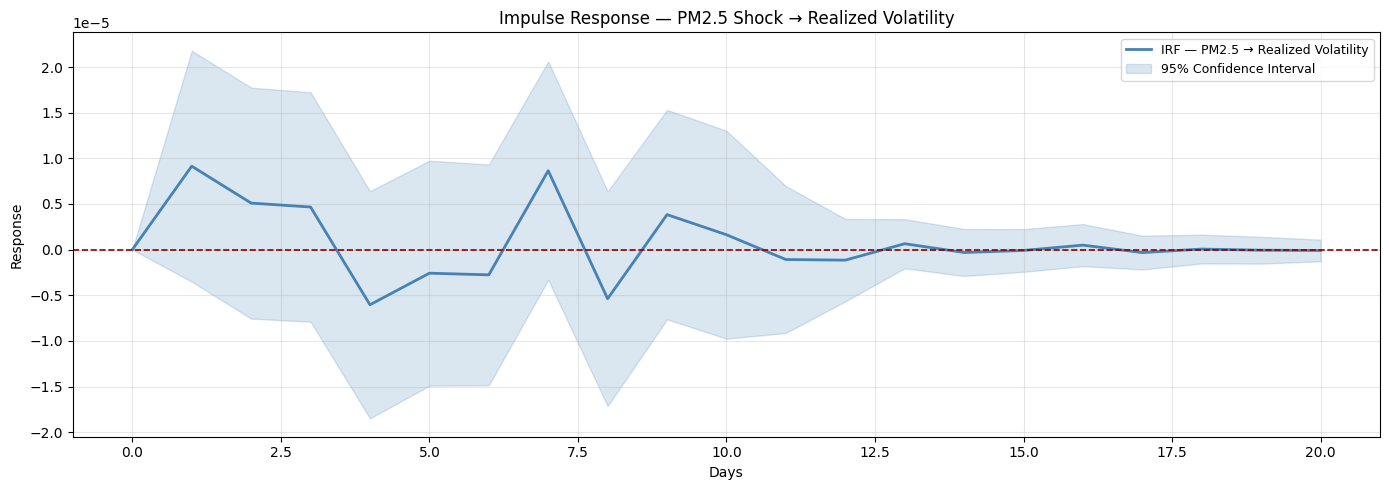

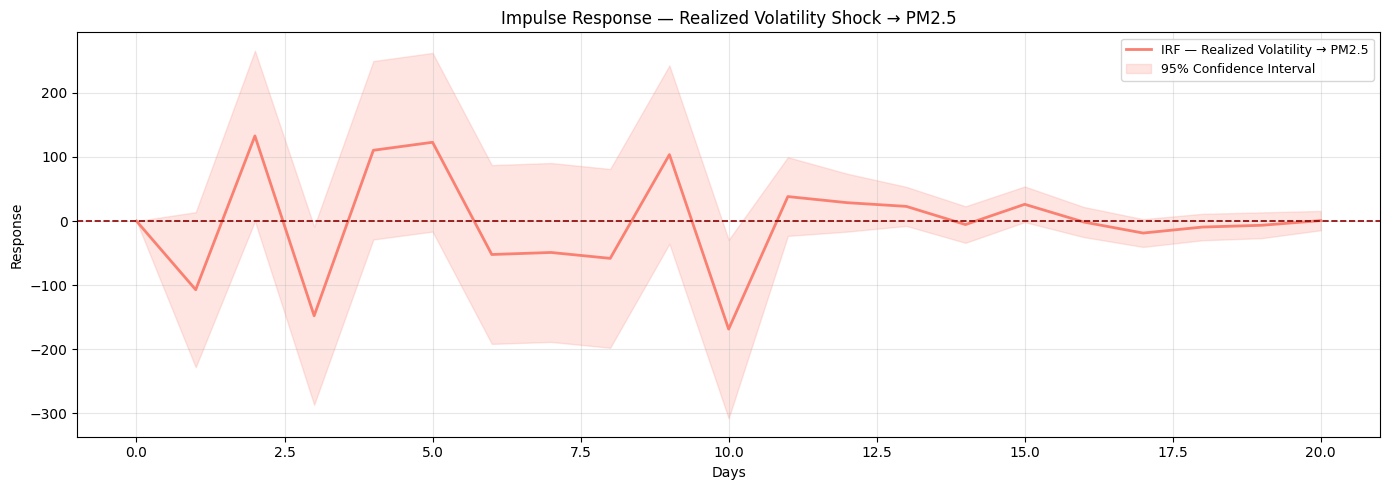

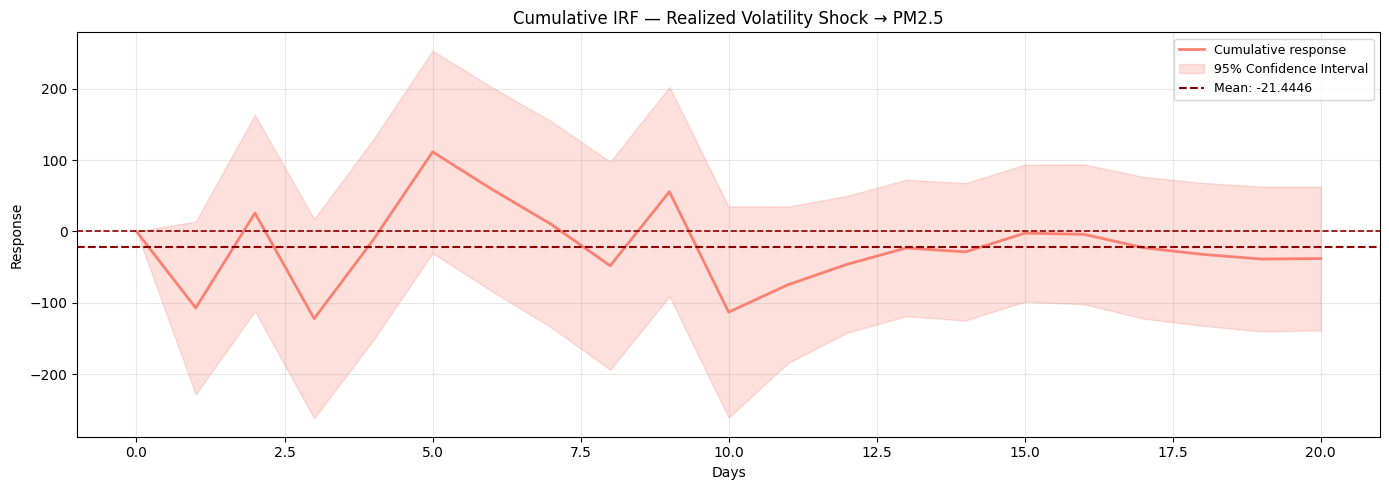

In [ ]:
# IRF
irf       = var_results.irf(20)
VARIABLES = var_results.names
rv_ix     = VARIABLES.index('rv_diff')
pm_ix     = VARIABLES.index('pm25_diff')

# Récupération des erreurs standards (CORRIGÉ ICI)
stderr     = irf.stderr()
cum_stderr = irf.cum_effect_stderr() 
z_score    = 1.96  # 95% CI

BLUE = 'steelblue'
RED  = 'salmon'
DARK = 'darkred'

def style_ax(ax, title):
    ax.set_title(title, fontsize=12)
    ax.axhline(0, color=DARK, linestyle='--', lw=1.2)
    ax.set_xlabel('Days')
    ax.set_ylabel('Response')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)

horizon = np.arange(len(irf.irfs))

# ── PM2.5 → RV ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
vals = irf.irfs[:, rv_ix, pm_ix]
se_vals = stderr[:, rv_ix, pm_ix]
lower, upper = vals - z_score * se_vals, vals + z_score * se_vals

ax.plot(horizon, vals, color=BLUE, lw=2, label='IRF — PM2.5 → Realized Volatility')
ax.fill_between(horizon, lower, upper, color=BLUE, alpha=0.2, label='95% Confidence Interval')
style_ax(ax, 'Impulse Response — PM2.5 Shock → Realized Volatility')
plt.tight_layout()
plt.show()

# ── RV → PM2.5 ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
vals2 = irf.irfs[:, pm_ix, rv_ix]
se_vals2 = stderr[:, pm_ix, rv_ix]
lower2, upper2 = vals2 - z_score * se_vals2, vals2 + z_score * se_vals2

ax.plot(horizon, vals2, color=RED, lw=2, label='IRF — Realized Volatility → PM2.5')
ax.fill_between(horizon, lower2, upper2, color=RED, alpha=0.2, label='95% Confidence Interval')
style_ax(ax, 'Impulse Response — Realized Volatility Shock → PM2.5')
plt.tight_layout()
plt.show()

# ── Cumulative RV → PM2.5 ─────────────────────────────────
# Utilisation de la méthode native cum_effects (CORRIGÉ ICI)
cum = irf.cum_effects[:, pm_ix, rv_ix]
cum_se_vals2 = cum_stderr[:, pm_ix, rv_ix]
cum_lower, cum_upper = cum - z_score * cum_se_vals2, cum + z_score * cum_se_vals2

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(horizon, cum, color=RED, lw=2, label='Cumulative response')
ax.fill_between(horizon, cum_lower, cum_upper, color=RED, alpha=0.25, label='95% Confidence Interval')
ax.axhline(cum.mean(), color=DARK, linestyle='--', lw=1.5,
           label=f'Mean: {cum.mean():.4f}')
style_ax(ax, 'Cumulative IRF — Realized Volatility Shock → PM2.5')
plt.tight_layout()
plt.show()

IRFs confirm that no statistically significant relationship can be established in either direction between PM2.5 and realized volatility, as all response curves remain within their 95% confidence intervals throughout the 20-day horizon. 

The reverse direction (RV → PM2.5) shows large oscillations with very wide confidence intervals, which does not necessarily imply the absence of a relationship, but rather that the signal is too noisy to draw robust conclusions. 

The only economically meaningful signal is the cumulative IRF, whose negative mean (-21.4) suggests that a volatility shock tends to reduce pollution over time. 